## Key Insights

- **Content growth**: Netflix additions peaked in **2019** for movies (1,424 titles) 
  and **2020** for TV shows (594 titles), with movies outnumbering TV shows overall — 
  though the gap narrowed sharply after 2018 as Netflix invested more heavily in 
  original series.
- **Geographic concentration**: The US alone accounts for **36.8%** of the catalog 
  (3,642 titles), followed distantly by **India (1,045, ~11%)** and the 
  **UK (785, ~8%)**, showing a still US-centric library despite Netflix's global reach.
- **Genre patterns**: **International Movies (2,752)** and **Dramas (2,427)** dominate 
  the catalog, together accounting for over a fifth of all genre tags — reflecting 
  how Netflix's tagging leans on broad, catch-all categories rather than niche labels.
- **Audience skew**: **TV-MA and TV-14** content makes up **61.1%** of the catalog, 
  reinforcing that Netflix's core library targets teen/adult viewers over young children.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

### Loading and Inspecting data:

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [6]:
df = pd.read_csv("netflix_titles.csv") 

print(df.shape)
print(df.info())
print(df.isnull().sum())
df.head()

(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
descr

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Data Cleaning:

In [8]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

In [9]:
df = df.dropna(subset=['year_added'])

In [10]:
df['genres'] = df['listed_in'].str.split(', ')
df['countries'] = df['country'].str.split(', ')

### Movies vs TV Shows over time:

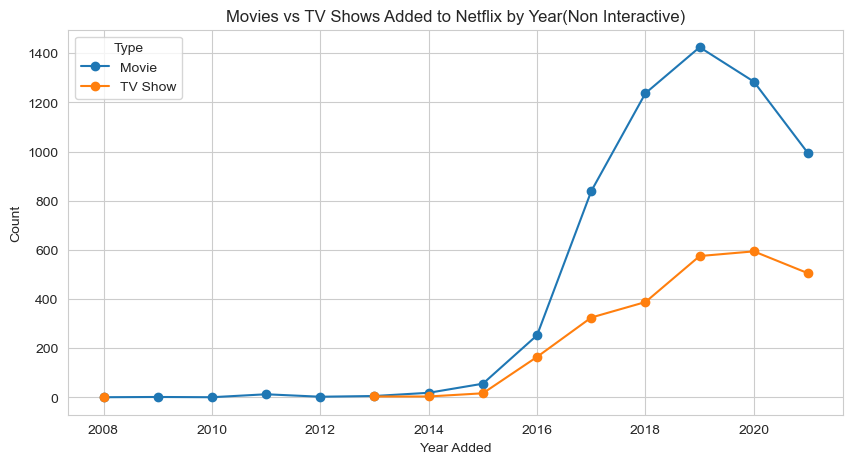

In [11]:
trend = df.groupby(['year_added', 'type']).size().unstack()

trend.plot(kind='line', marker='o')
plt.title("Movies vs TV Shows Added to Netflix by Year(Non Interactive)")
plt.xlabel("Year Added")
plt.ylabel("Count")
plt.legend(title="Type")
plt.show()

Content additions grew sharply from 2015 to 2019, with total titles added per year is more than previous year in that period. Movies have consistently outnumbered TV shows every year, but the gap has narrowed since 2018 as Netflix invested more heavily in original series. 2019-2020 marks the peak year for additions, after which growth slows around 2021 — likely reflecting both catalog maturity and pandemic-era production slowdowns. This suggests Netflix's early growth strategy depended on licensing movies, while TV Shows became a bigger strategic focus in later years.


### Top 10 Countries based on Content Generation:

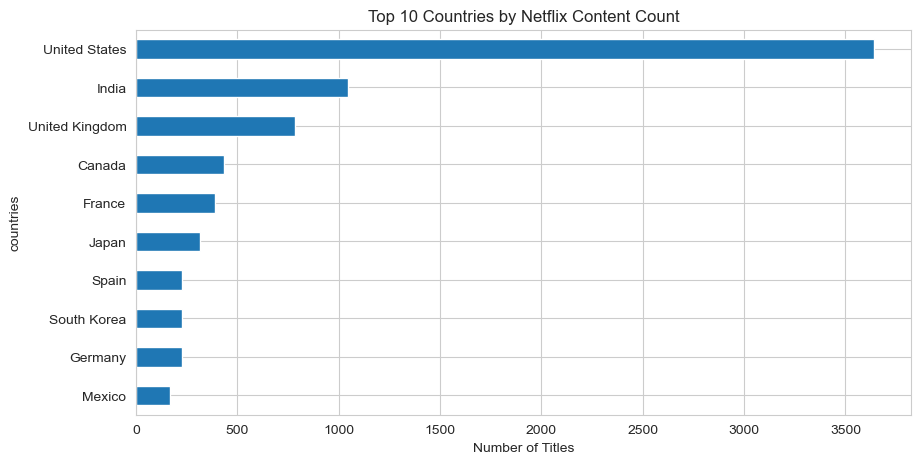

In [12]:
country_exploded = df.explode('countries')
top_countries = country_exploded['countries'].value_counts().head(10)
top_countries.plot(kind='barh')
plt.title("Top 10 Countries by Netflix Content Count")
plt.xlabel("Number of Titles")
plt.gca().invert_yaxis()
plt.show()

The United States dominates Netflix's catalog by a wide margin, accounting for roughly a third of all titles, followed by India and the United Kingdom. This heavy US-centric skew makes sense given Netflix's origins and headquarters, but the strong India presence reflects deliberate investment in regional content to grow subscribers there. The remaining top 10 countries each contribute a much smaller share, showing that despite being a "global" platform, Netflix's catalog is still fairly concentrated in a handful of major markets.

### Top 10 Content Genres:

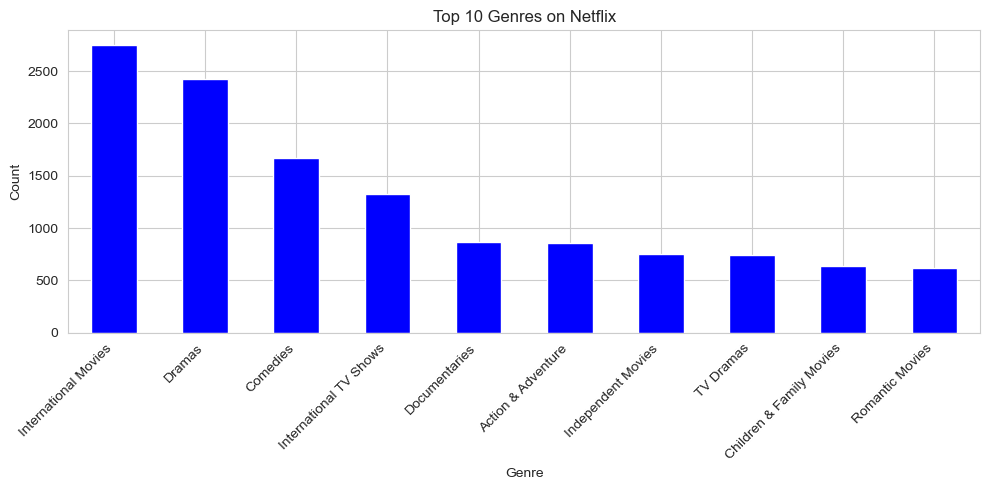

In [15]:
genre_exploded = df.explode('genres')
top_genres = genre_exploded['genres'].value_counts().head(10)
top_genres.plot(kind='bar', color='blue')
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

International Movies and Dramas dictates Netflix's genre tags, together accounting for a large share of all titles — reflecting how the "listed_in" field often stacks broad, catch-all labels rather than niche ones. Comedy and Documentaries follow at a noticeable distance, showing Netflix leans heavily on story-driven content over factual programming. The long tail of genres (Anime, Sports, Cult Movies) each make up a small fraction, suggesting Netflix's catalog is broad in labeling but concentrated in a few dominant content types.

### Rating Distribution of Content:

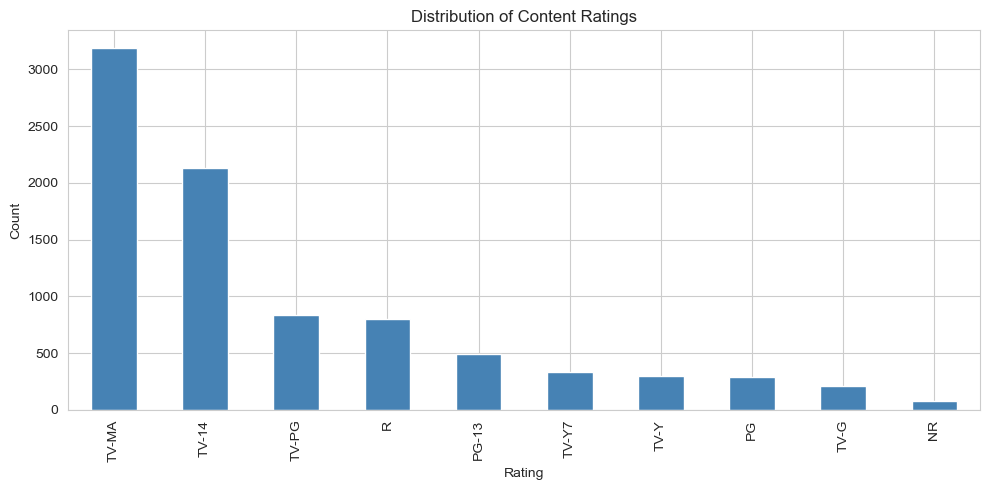

In [13]:
rating_counts = df['rating'].value_counts().head(10)

rating_counts.plot(kind='bar', color='steelblue')
plt.title("Distribution of Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

TV-MA and TV-14 are the most common ratings, together making up more than half of all titles — indicating Netflix's catalog skews toward teen and adult audiences rather than young children. Kid-friendly ratings like TV-Y and TV-G appear much less frequently, suggesting children's content is a smaller, more curated part of the library compared to services built specifically for kids. This distribution aligns with Netflix's broader positioning as a general entertainment platform rather than a family-friendly streaming platform.

### Genre Co-Occurence Heatmap:

In [14]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


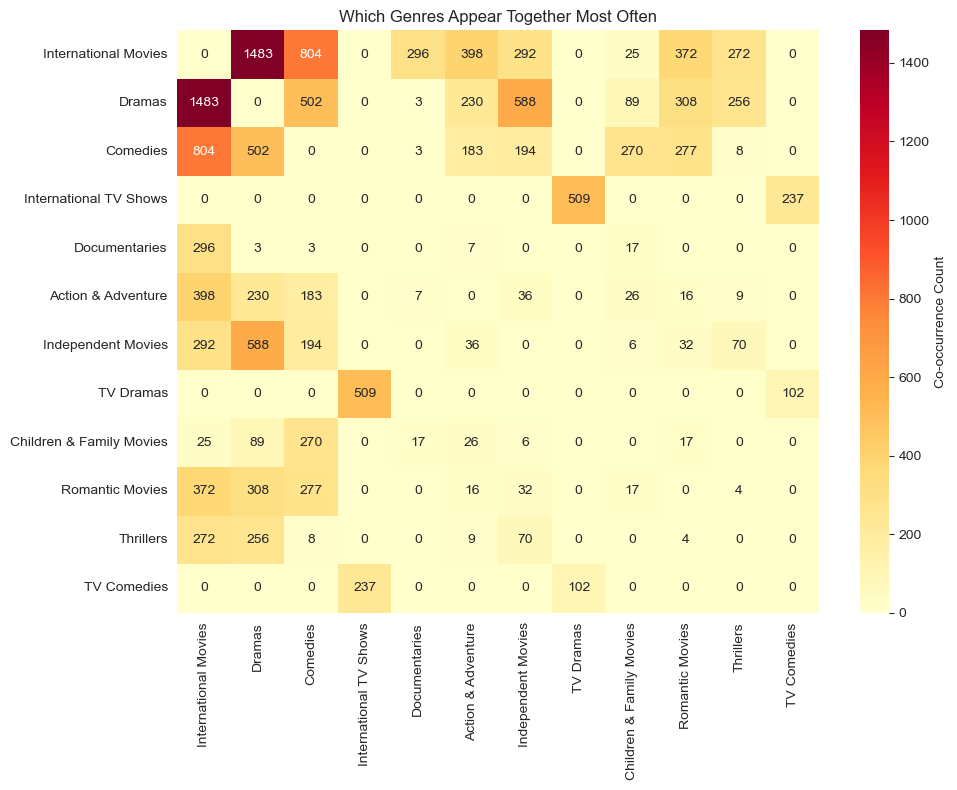

In [16]:
from itertools import combinations
import numpy as np
top_n_genres = genre_exploded['genres'].value_counts().head(12).index.tolist()
co_matrix = pd.DataFrame(0, index=top_n_genres, columns=top_n_genres)

for genre_list in df['genres'].dropna():
    relevant = [g for g in genre_list if g in top_n_genres]
    for g1, g2 in combinations(relevant, 2):
        co_matrix.loc[g1, g2] += 1
        co_matrix.loc[g2, g1] += 1 

plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Co-occurrence Count'})
plt.title("Which Genres Appear Together Most Often")
plt.tight_layout()
plt.show()

International Movies and Dramas co-occur far more than any other pair, confirming that Netflix frequently tags the same title with both — likely because "International" functions more as a regional flag than a genre. Comedies pair heavily with Romantic Movies, reflecting the classic rom-com bundling pattern. Genres like Documentaries and Anime show almost no overlap with others, suggesting these are treated as more standalone categories rather than blended with dramas or comedies.

### Word Cloud of Descriptions:

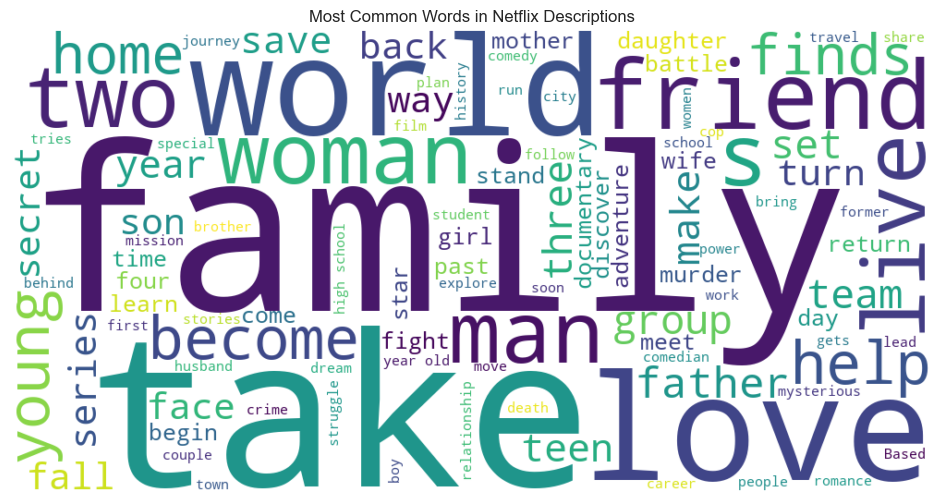

In [17]:
from wordcloud import WordCloud, STOPWORDS
text = " ".join(df['description'].dropna())
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(["life", "one", "new", "must", "find", "will"])
wc = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="viridis",
    max_words=100
).generate(text)
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Netflix Descriptions")
plt.show()

Words like "family," "love," and "young" appear most prominently, suggesting a large share of Netflix's catalog centers on personal and relationship-driven storylines rather than plot-heavy premises. Genre-adjacent words like "murder," "secret," and "father" also stand out, hinting at drama and crime being recurring narrative hooks across many titles. Word clouds are a blunt tool though — they show frequency, not context, so a word like "life" could belong to a documentary or a romantic drama equally.

### Duration Analysis:

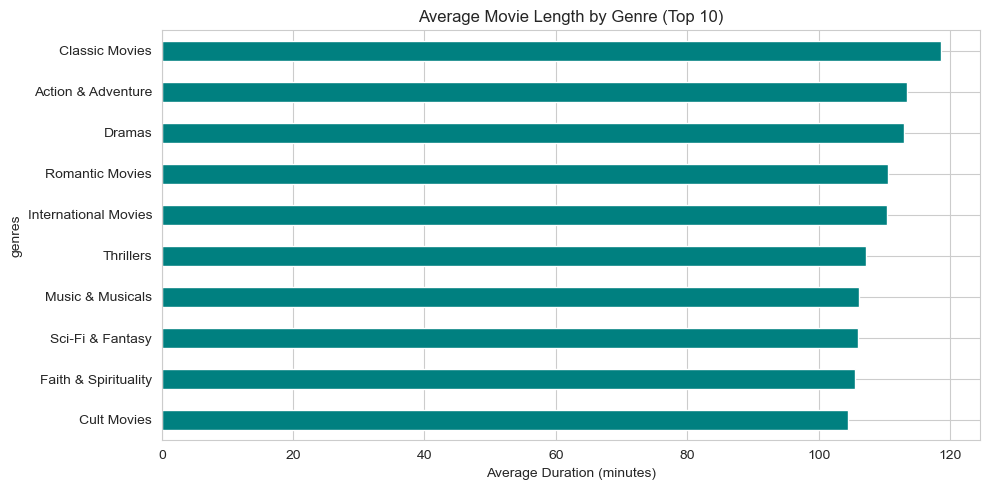

In [33]:
movies = df[df['type'] == 'Movie'].copy()
tv_shows = df[df['type'] == 'TV Show'].copy()
movies['duration_mins'] = movies['duration'].str.extract('(\d+)').astype(float)
tv_shows['duration_seasons'] = tv_shows['duration'].str.extract('(\d+)').astype(float)
movies_exploded = movies.explode('genres')
avg_duration_by_genre = movies_exploded.groupby('genres')['duration_mins'].mean().sort_values(ascending=False).head(10)
avg_duration_by_genre.plot(kind='barh', color='teal')
plt.title("Average Movie Length by Genre (Top 10)")
plt.xlabel("Average Duration (minutes)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

While every genre has almost similar duration of the content, Classic Movies have the most duration and Cult Movies have the least. Average Movie length lies within 100 to 120 minutes across all genres, hence it is an inconclusive factor for predicting most popular genre.

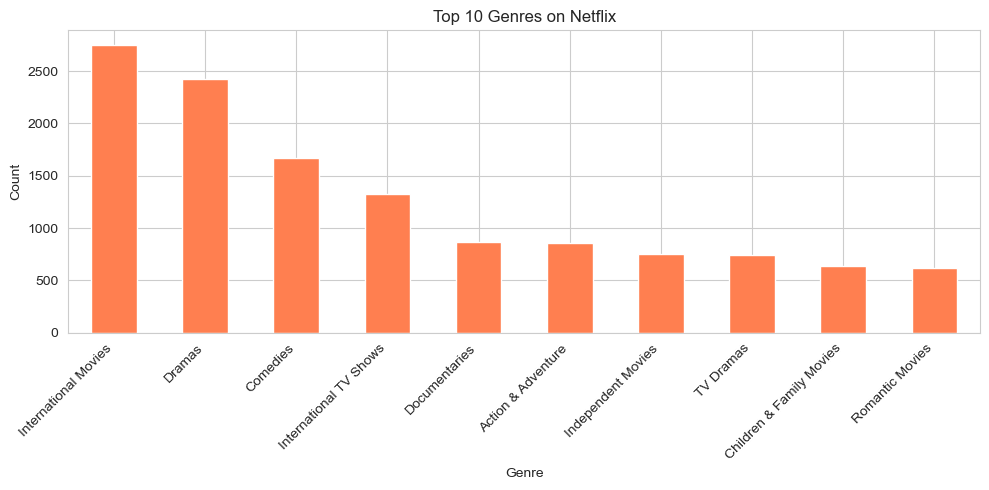

In [18]:
top_genres.plot(kind='bar', color='coral')
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("top_genres.png", dpi=150, bbox_inches='tight')  # saves to your working directory
plt.show()


In [19]:
import os
print(os.path.abspath("top_genres.png"))

C:\Users\KIIT\Documents\Anaconda Learnings\top_genres.png


In [20]:
print("Peak movie year:", trend['Movie'].idxmax(), "-", int(trend['Movie'].max()))
print("Peak TV year:", trend['TV Show'].idxmax(), "-", int(trend['TV Show'].max()))
print("\nTop countries:\n", top_countries)
print("\nUS %:", round(top_countries.iloc[0] / country_exploded['countries'].count() * 100, 1))
print("\nTop genres:\n", top_genres)
print("\nRatings:\n", rating_counts)
print("TV-MA + TV-14 %:", round((rating_counts['TV-MA'] + rating_counts['TV-14']) / df['rating'].notna().sum() * 100, 1))

Peak movie year: 2019.0 - 1424
Peak TV year: 2020.0 - 594

Top countries:
 countries
United States     3642
India             1045
United Kingdom     785
Canada             432
France             389
Japan              314
Spain              228
South Korea        226
Germany            225
Mexico             169
Name: count, dtype: int64

US %: 36.8

Top genres:
 genres
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1328
Documentaries                869
Action & Adventure           859
Independent Movies           756
TV Dramas                    739
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

Ratings:
 rating
TV-MA    3183
TV-14    2133
TV-PG     838
R         799
PG-13     490
TV-Y7     330
TV-Y      300
PG        287
TV-G      212
NR         78
Name: count, dtype: int64
TV-MA + TV-14 %: 61.1


In [24]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [22]:
import plotly.express as px
import plotly.graph_objects as go

### Genre hierarchy by content count:

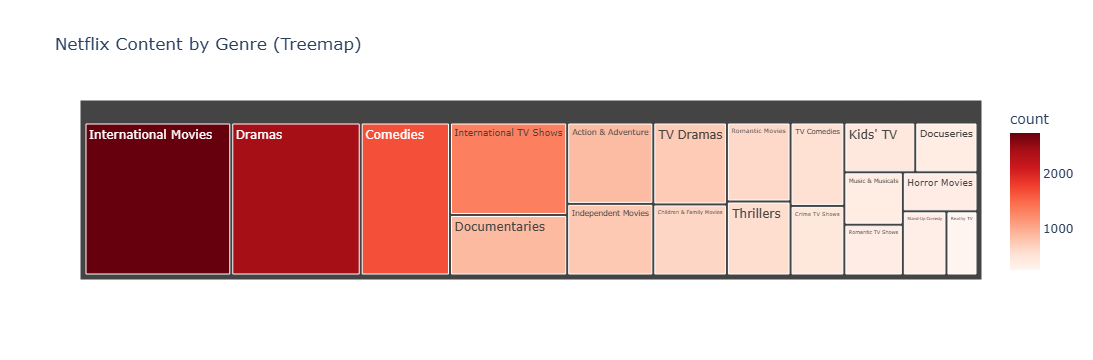

In [26]:
genre_counts = genre_exploded['genres'].value_counts().reset_index()
genre_counts.columns = ['genre', 'count']

fig = px.treemap(
    genre_counts.head(20), 
    path=['genre'], 
    values='count',
    title='Netflix Content by Genre (Treemap)',
    color='count',
    color_continuous_scale='Reds'
)
fig.show()

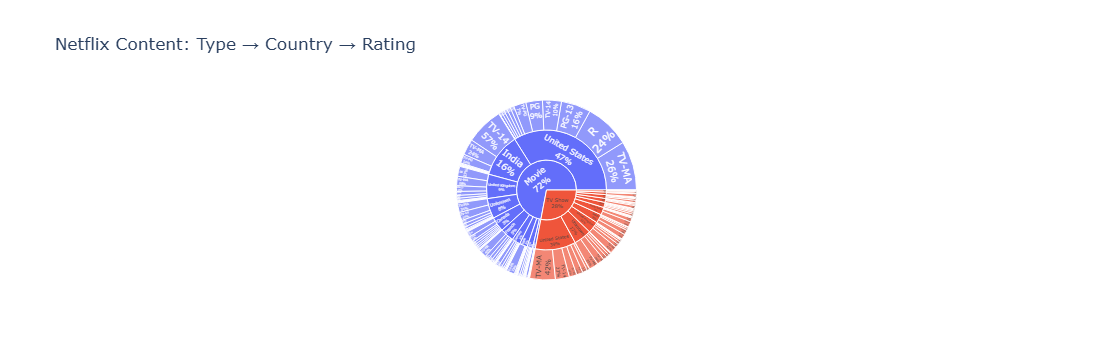

In [23]:
sunburst_df = country_exploded.copy()
sunburst_df['rating'] = (
    sunburst_df['rating']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
    .replace('', 'Unknown')
)
sunburst_df['countries'] = (
    sunburst_df['countries']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
)
top_10_countries = sunburst_df['countries'].value_counts().head(10).index
sunburst_df = sunburst_df[
    sunburst_df['countries'].isin(top_10_countries)
]
fig = px.sunburst(
    sunburst_df,
    path=['type', 'countries', 'rating'],
    title='Netflix Content: Type → Country → Rating'
)
fig.update_traces(textinfo='label+percent parent')
fig.show()

### Genre growth by Year:

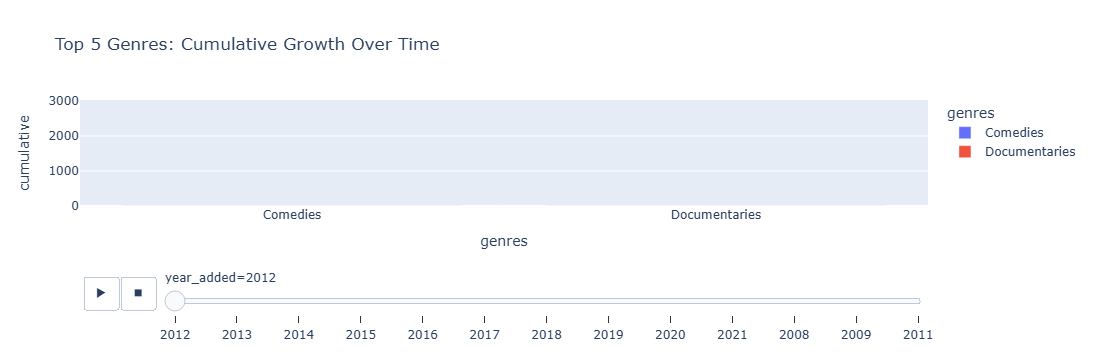

In [32]:
genre_year = (
    genre_exploded
    .groupby(['year_added', 'genres'])
    .size()
    .reset_index(name='count')
)
top_5_genres = genre_counts.head(5)['genre'].tolist()
genre_year_top5 = genre_year[
    genre_year['genres'].isin(top_5_genres)
].copy()
genre_year_top5['year_added'] = pd.to_numeric(
    genre_year_top5['year_added'],
    errors='coerce'
)
genre_year_top5 = genre_year_top5.dropna(subset=['year_added'])
genre_year_top5['year_added'] = genre_year_top5['year_added'].astype(int)
genre_year_top5 = genre_year_top5.sort_values(
    ['genres', 'year_added']
)
genre_year_top5['cumulative'] = (
    genre_year_top5.groupby('genres')['count'].cumsum()
)
fig = px.bar(
    genre_year_top5,
    x='genres',
    y='cumulative',
    color='genres',
    animation_frame='year_added',
    range_y=[0, genre_year_top5['cumulative'].max() * 1.1],
    title='Top 5 Genres: Cumulative Growth Over Time'
)
fig.show()

In [31]:
print(genre_counts.head())
print(genre_counts.columns)

                    genre  count
0    International Movies   2752
1                  Dramas   2427
2                Comedies   1674
3  International TV Shows   1328
4           Documentaries    869
Index(['genre', 'count'], dtype='object')


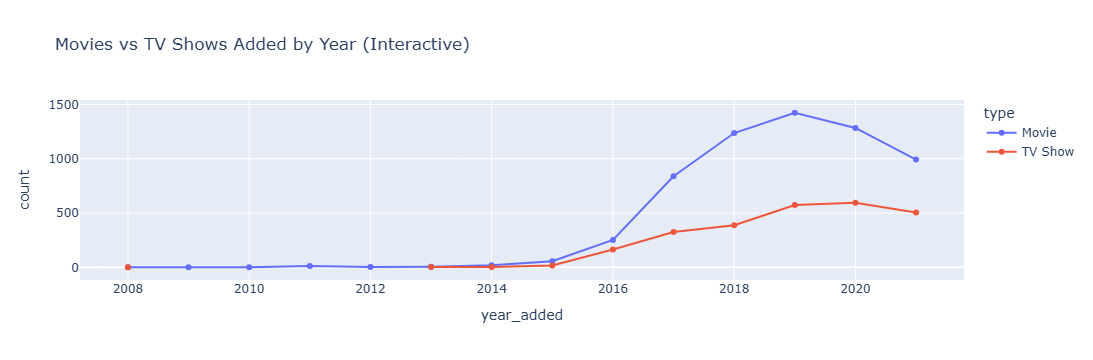

In [24]:
trend_reset = trend.reset_index().melt(id_vars='year_added', var_name='type', value_name='count')

fig = px.line(
    trend_reset, x='year_added', y='count', color='type',
    markers=True,
    title='Movies vs TV Shows Added by Year (Interactive)'
)
fig.show()

### Countries with Most Mature Content (Average Rating Score)

In [36]:
rating_rank = {
    'TV-Y': 0, 'TV-G': 1, 'G': 1,
    'TV-Y7': 2,
    'PG': 3, 'TV-PG': 3,
    'PG-13': 4,
    'TV-14': 5,
    'R': 6,
    'TV-MA': 7,
    'NC-17': 7
}
country_exploded['rating_score'] = country_exploded['rating'].map(rating_rank)

country_rating = (
    country_exploded
    .dropna(subset=['rating_score'])
    .groupby('countries')['rating_score']
    .mean()
)

In [37]:
country_counts = country_exploded['countries'].value_counts()

country_rating = country_rating[
    country_rating.index.isin(country_counts[country_counts > 50].index)
]

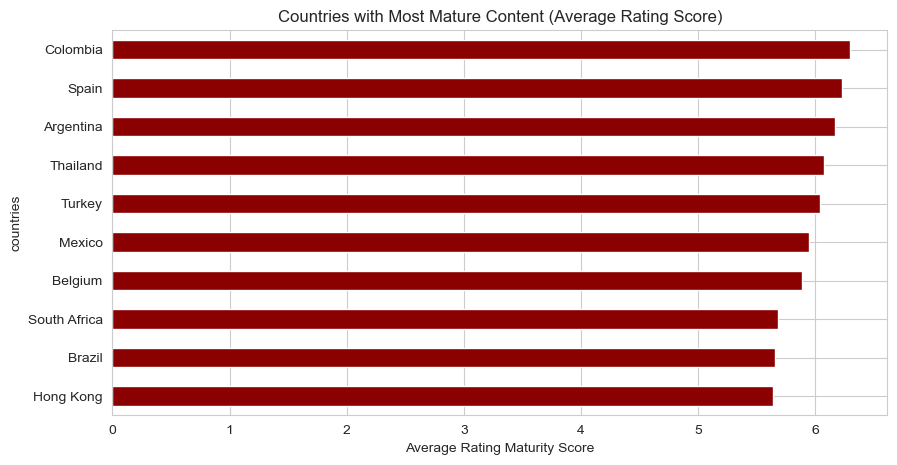

In [38]:
top_mature = country_rating.sort_values(ascending=False).head(10)
top_mature.plot(kind='barh', color='darkred')
plt.title("Countries with Most Mature Content (Average Rating Score)")
plt.xlabel("Average Rating Maturity Score")
plt.gca().invert_yaxis()
plt.show()

Content maturity varies meaningfully by country, with Colombia skewing furthest toward mature ratings (TV-MA/R), while Hong Kong appears comparatively less mature among the highest-ranked countries in this analysis. This likely reflects differing content strategies and cultural norms across markets—some regions rely more heavily on licensed international dramas, crime series, and mature originals, while others emphasize broader audience appeal. Worth noting: this metric is sensitive to sample size, so countries with fewer than 50 titles were excluded to avoid noisy results.

###  How has Netflix shifted from movies to TV shows?

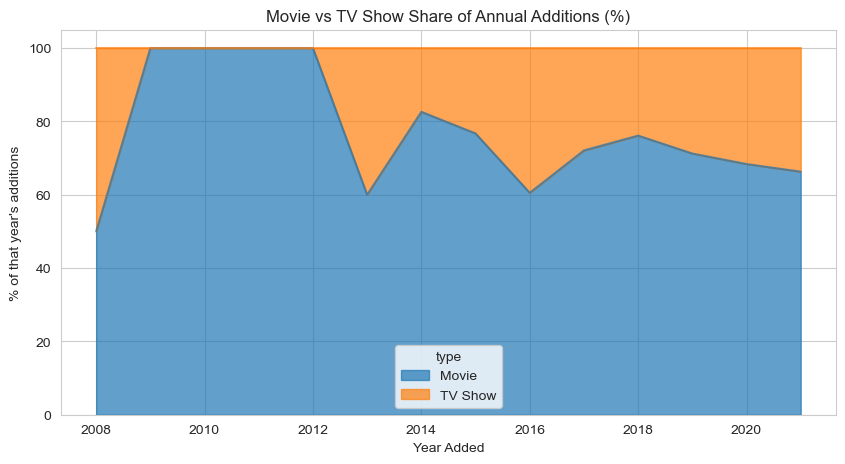

In [25]:
type_share = df.groupby(['year_added', 'type']).size().unstack()
type_pct = type_share.div(type_share.sum(axis=1), axis=0) * 100

type_pct.plot(kind='area', stacked=True, alpha=0.7)
plt.title("Movie vs TV Show Share of Annual Additions (%)")
plt.ylabel("% of that year's additions")
plt.xlabel("Year Added")
plt.show()

Movies made up the vast majority of annual additions in Netflix's early years, but TV Shows' share of new content has grown steadily since 2016, increasing by roughly 1.5–2× as a share of yearly additions. This mirrors the industry-wide shift toward prestige TV and reflects Netflix's push into serialized originals to boost subscriber retention. Even so, movies still represent the majority of yearly additions in the most recent years of the dataset.

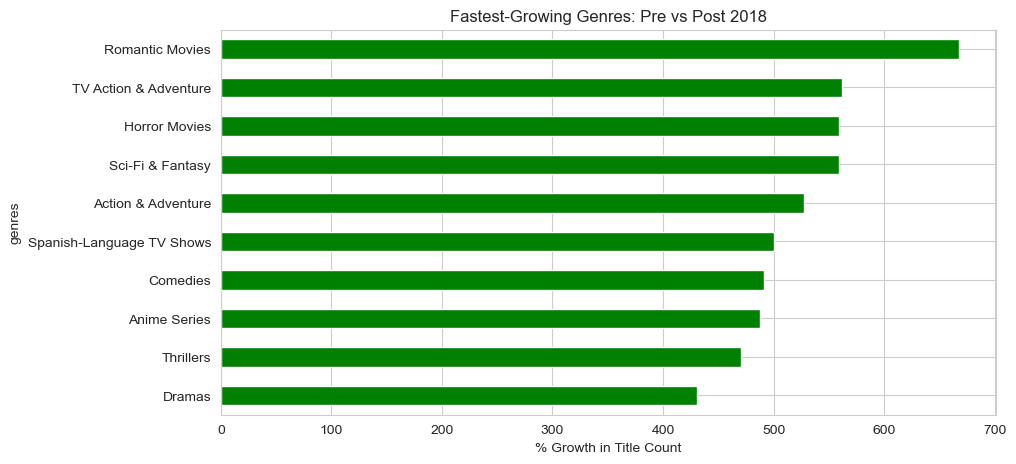

In [26]:
pre_2018 = genre_exploded[genre_exploded['year_added'] < 2018]['genres'].value_counts()
post_2018 = genre_exploded[genre_exploded['year_added'] >= 2018]['genres'].value_counts()
growth = pd.DataFrame({'pre_2018': pre_2018, 'post_2018': post_2018}).fillna(0)
growth = growth[growth['pre_2018'] > 20]  
growth['growth_pct'] = (growth['post_2018'] - growth['pre_2018']) / growth['pre_2018'] * 100
top_growth = growth.sort_values('growth_pct', ascending=False).head(10)
top_growth['growth_pct'].plot(kind='barh', color='green')
plt.title("Fastest-Growing Genres: Pre vs Post 2018")
plt.xlabel("% Growth in Title Count")
plt.gca().invert_yaxis()
plt.show()

International Movies and Dramas show the strongest growth after 2018, with title counts increasing substantially compared with the pre-2018 period, suggesting these became key investment areas as Netflix expanded globally. In contrast, genres such as Documentaries grew more gradually, indicating a shift in programming priorities rather than uniform catalog expansion. Genres with fewer than 20 pre-2018 titles were excluded to avoid inflated percentage swings from very small sample sizes.

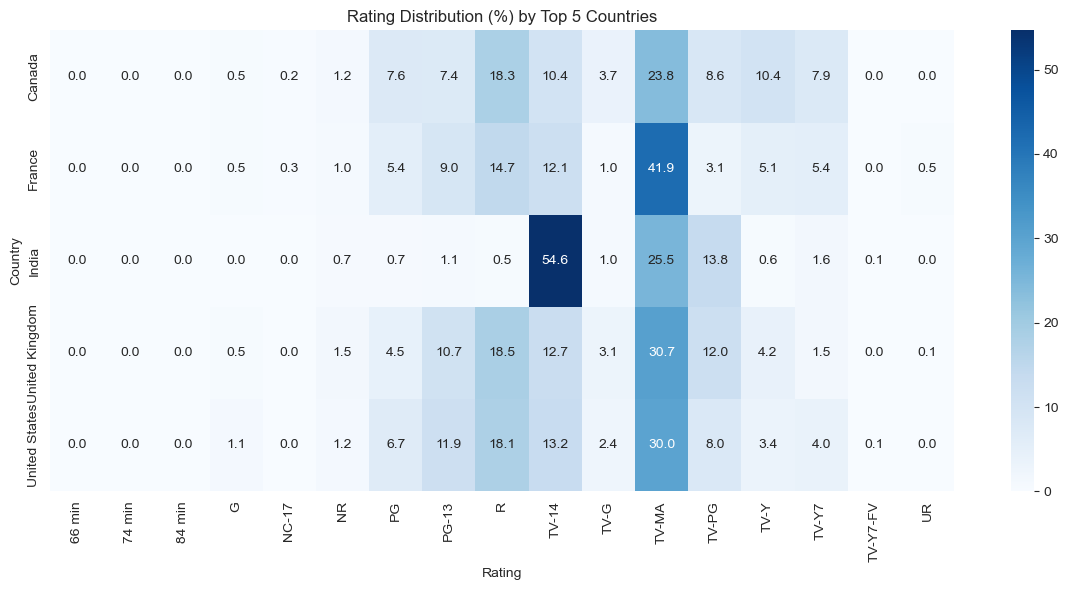

In [30]:
top_5_countries = country_exploded['countries'].value_counts().head(5).index

filtered = country_exploded[
    country_exploded['countries'].isin(top_5_countries)
].copy()
filtered = filtered.dropna(subset=['rating'])

country_rating_ct = pd.crosstab(
    filtered['countries'],
    filtered['rating']
)
country_rating_pct = (
    country_rating_ct.div(country_rating_ct.sum(axis=1), axis=0) * 100
)
plt.figure(figsize=(12, 6))
sns.heatmap(
    country_rating_pct,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)
plt.title("Rating Distribution (%) by Top 5 Countries")
plt.xlabel("Rating")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

Rating distributions differ noticeably across the top five countries. France has the strongest concentration of TV-MA content (≈42%), while India is dominated by TV-14 titles (≈55%), reflecting a much more teen-oriented catalog. The United States and United Kingdom show a more balanced mix across TV-MA, TV-14, and R-rated content. These differences suggest Netflix tailors its content acquisition and production strategy to regional audience preferences rather than applying a single global maturity profile.

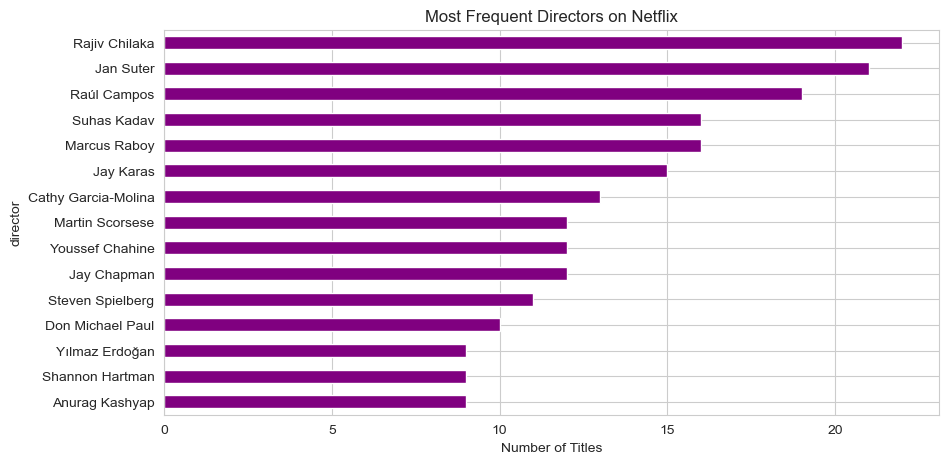

In [43]:
director_counts = df['director'].dropna().str.split(', ').explode().value_counts().head(15)
director_counts.plot(kind='barh', color='purple')
plt.title("Most Frequent Directors on Netflix")
plt.xlabel("Number of Titles")
plt.gca().invert_yaxis()
plt.show()

Rajiv Chilaka appears most frequently in the catalog with the highest number of titles. However, closer inspection shows that many of the most prolific directors are associated with children's programming, stand-up comedy specials, anthology series, or documentary-style productions, rather than only traditional feature films. As a result, raw appearance counts reflect content production patterns and release formats as much as individual directorial prominence.

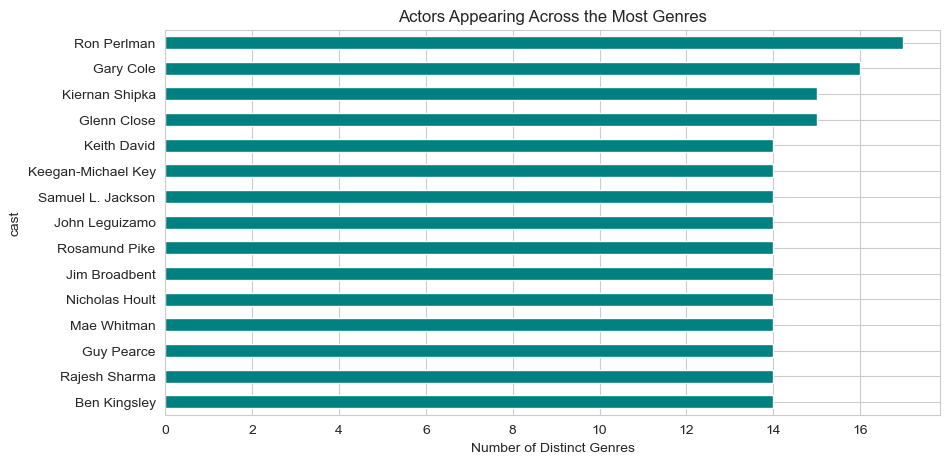

In [44]:
cast_genre = df[['cast', 'genres']].dropna()
cast_genre['cast'] = cast_genre['cast'].str.split(', ')
cast_genre_exploded = cast_genre.explode('cast').explode('genres')
actor_genre_diversity = cast_genre_exploded.groupby('cast')['genres'].nunique().sort_values(ascending=False)
actor_title_count = cast_genre_exploded.groupby('cast').size()
actor_genre_diversity = actor_genre_diversity[actor_title_count >= 5].head(15)
actor_genre_diversity.plot(kind='barh', color='teal')
plt.title("Actors Appearing Across the Most Genres")
plt.xlabel("Number of Distinct Genres")
plt.gca().invert_yaxis()
plt.show()

Ron Perlman appears across 17 distinct genres, suggesting a career built on remarkable genre versatility rather than typecasting. Other highly versatile actors in the catalog include Gary Cole (16 genres) and Kiernan Shipka and Glenn Close (15 genres each). This analysis was filtered to actors with at least five titles to avoid one-off appearances artificially inflating the "genre diversity" metric.

### Release year vs date added (lag analysis):

In [1]:
from scipy import stats

In [27]:
df['days_to_add'] = (df['date_added'] - pd.to_datetime(df['release_year'], format='%Y')).dt.days
lag_by_year = df.groupby('release_year')['days_to_add'].mean().dropna()
corr, p_value = stats.pearsonr(lag_by_year.index, lag_by_year.values)
print(f"Correlation between release year and lag-to-add: r={corr:.3f}, p={p_value:.4f}")

Correlation between release year and lag-to-add: r=-0.999, p=0.0000


### Is content type (Movie/TV) independent of rating?

In [28]:
contingency = pd.crosstab(df['type'], df['rating'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p:.6f}")
print(f"Degrees of freedom: {dof}")

if p < 0.05:
    print("Result: Reject H0 — content type and rating ARE significantly associated")
else:
    print("Result: Fail to reject H0 — no significant association found")

Chi-square statistic: 1021.88
p-value: 0.000000
Degrees of freedom: 16
Result: Reject H0 — content type and rating ARE significantly associated


### Is country independent of rating maturity?

In [31]:
top_5_country_df = country_exploded[country_exploded['countries'].isin(top_5_countries)]
contingency2 = pd.crosstab(top_5_country_df['countries'], top_5_country_df['rating'])
chi2_2, p_2, dof_2, expected_2 = stats.chi2_contingency(contingency2)

print(f"\nCountry vs Rating — Chi-square: {chi2_2:.2f}, p-value: {p_2:.6f}")


Country vs Rating — Chi-square: 1394.18, p-value: 0.000000


### Do movies added post-2018 have different durations than movies added pre-2018? (Independent t-test)

In [34]:
pre_2018_duration = movies[movies['year_added'] < 2018]['duration_mins'].dropna()
post_2018_duration = movies[movies['year_added'] >= 2018]['duration_mins'].dropna()

t_stat, p_val = stats.ttest_ind(pre_2018_duration, post_2018_duration, equal_var=False)

print(f"\nT-test: pre-2018 mean={pre_2018_duration.mean():.1f} min, "
      f"post-2018 mean={post_2018_duration.mean():.1f} min")
print(f"t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: Statistically significant difference in movie length before/after 2018")
else:
    print("Result: No statistically significant difference found")


T-test: pre-2018 mean=92.0 min, post-2018 mean=101.4 min
t-statistic: -10.619, p-value: 0.0000
Result: Statistically significant difference in movie length before/after 2018
